# ML No Supervisado

In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns


## Datos

In [7]:
from sklearn.datasets import load_iris


iris = load_iris()
X = iris.data
y = iris.target

In [11]:
print("Nombres de las características:")
print(iris.feature_names)


print("\nNombres de las especies:")
print(iris.target_names)

Nombres de las características:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Nombres de las especies:
['setosa' 'versicolor' 'virginica']


In [8]:
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [12]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = iris.target

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

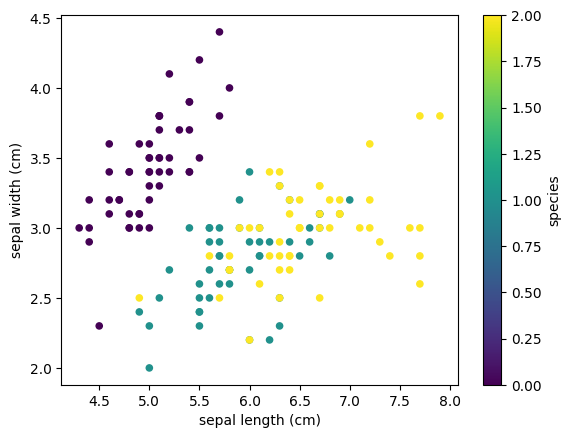

In [13]:
df.plot(kind='scatter', x='sepal length (cm)', y='sepal width (cm)', c='species', colormap='viridis')

## Clustering

Clustering is a machine learning technique used to group data based on similarity, with applications in customer segmentation and anomaly detection.

K-means clustering partitions data into clusters based on the distance between data points and centroids but struggles with imbalanced or non-convex clusters.

Heuristic methods such as silhouette analysis, the elbow method, and the Davies-Bouldin Index help assess k-means performance.

DBSCAN is a density-based algorithm that creates clusters based on density and works well with natural, irregular patterns.

HDBSCAN is a variant of DBSCAN that does not require parameters and uses cluster stability to find clusters.

Hierarchical clustering can be divisive (top-down) or agglomerative (bottom-up) and produces a dendrogram to visualize the cluster hierarchy.

Dimension reduction simplifies data structure, improves clustering outcomes, and is useful in tasks such as face recognition (using eigenfaces).

Clustering and dimension reduction work together to improve model performance by reducing noise and simplifying feature selection.

PCA, a linear dimensionality reduction method, minimizes information loss while reducing dimensionality and noise in data.

t-SNE and UMAP are other dimensionality reduction techniques that map high-dimensional data into lower-dimensional spaces for visualization and analysis.



### K-Means

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

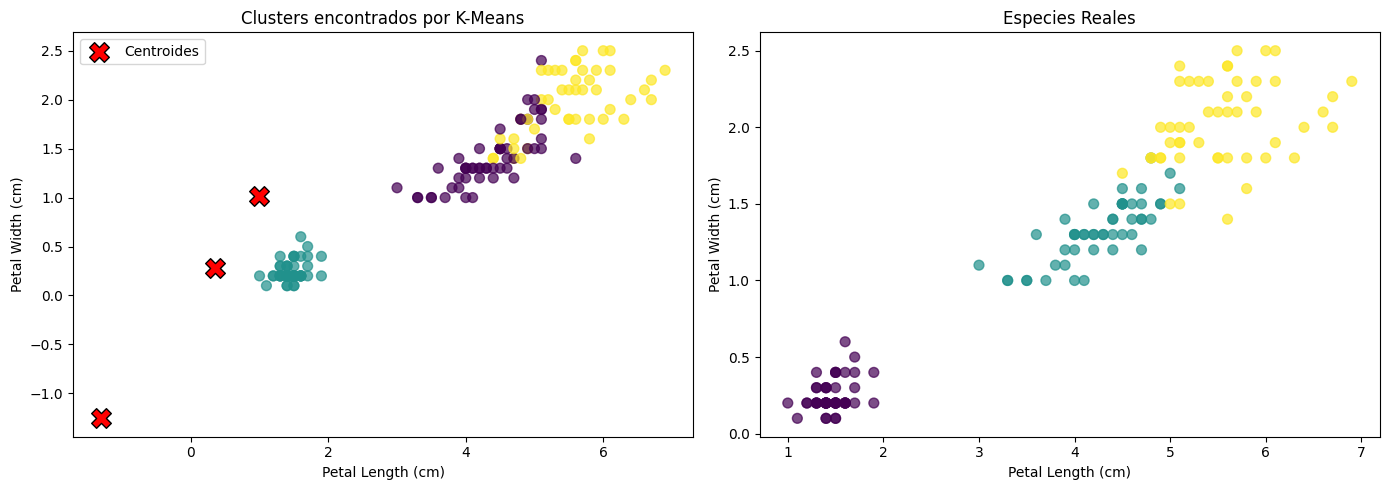

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(X[:, 2], X[:, 3], c=y_pred, cmap='viridis', s=50, alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 2], 
                kmeans.cluster_centers_[:, 3], 
                c='red', marker='X', s=200, edgecolors='black', label='Centroides')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Clusters encontrados por K-Means')
axes[0].legend()


axes[1].scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', s=50, alpha=0.7)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('Especies Reales')

plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

print(f"Adjusted Rand Score: {adjusted_rand_score(y, y_pred):.3f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, y_pred):.3f}")

Adjusted Rand Score: 0.620
Silhouette Score: 0.460


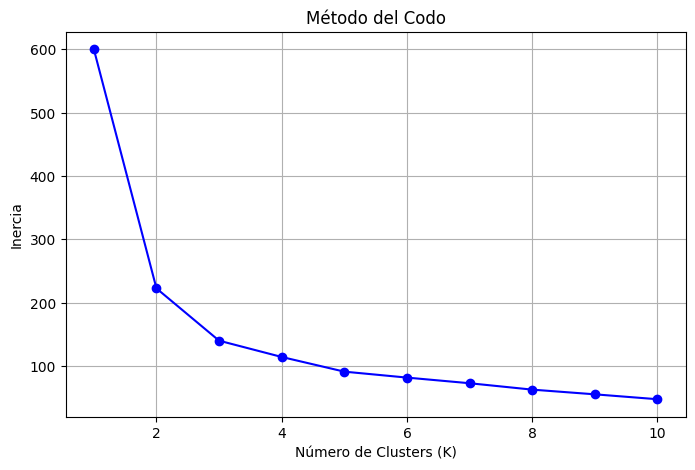

In [39]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

### DBSCAN and HDBSCAN

In [41]:
from sklearn.cluster import DBSCAN
import hdbscan

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
X_2d = X_scaled[:, 2:]

In [46]:
#DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)


n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan = list(labels_dbscan).count(-1)

print(f"Número de clusters encontrados: {n_clusters_dbscan}")
print(f"Número de puntos de ruido: {n_noise_dbscan}")
print(f"Etiquetas únicas: {set(labels_dbscan)}")


mask_dbscan = labels_dbscan != -1
if n_clusters_dbscan > 1:
    silhouette_dbscan = silhouette_score(X_scaled[mask_dbscan], labels_dbscan[mask_dbscan])
    print(f"Silhouette Score: {silhouette_dbscan:.3f}")

Número de clusters encontrados: 2
Número de puntos de ruido: 34
Etiquetas únicas: {0, 1, -1}
Silhouette Score: 0.656


In [45]:
#HDBSCAN

hdb = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5)
labels_hdbscan = hdb.fit_predict(X_scaled)

n_clusters_hdbscan = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise_hdbscan = list(labels_hdbscan).count(-1)

print(f"Número de clusters encontrados: {n_clusters_hdbscan}")
print(f"Número de puntos de ruido: {n_noise_hdbscan}")
print(f"Etiquetas únicas: {set(labels_hdbscan)}")


mask_hdbscan = labels_hdbscan != -1
if n_clusters_hdbscan > 1:
    silhouette_hdbscan = silhouette_score(X_scaled[mask_hdbscan], labels_hdbscan[mask_hdbscan])
    print(f"Silhouette Score: {silhouette_hdbscan:.3f}")


print(f"\nProbabilidades de pertenencia (primeras 10):")
print(hdb.probabilities_[:10])

Número de clusters encontrados: 2
Número de puntos de ruido: 2
Etiquetas únicas: {0, 1, -1}
Silhouette Score: 0.590

Probabilidades de pertenencia (primeras 10):
[1.         1.         1.         1.         1.         0.79635338
 0.79977516 1.         0.7316837  1.        ]


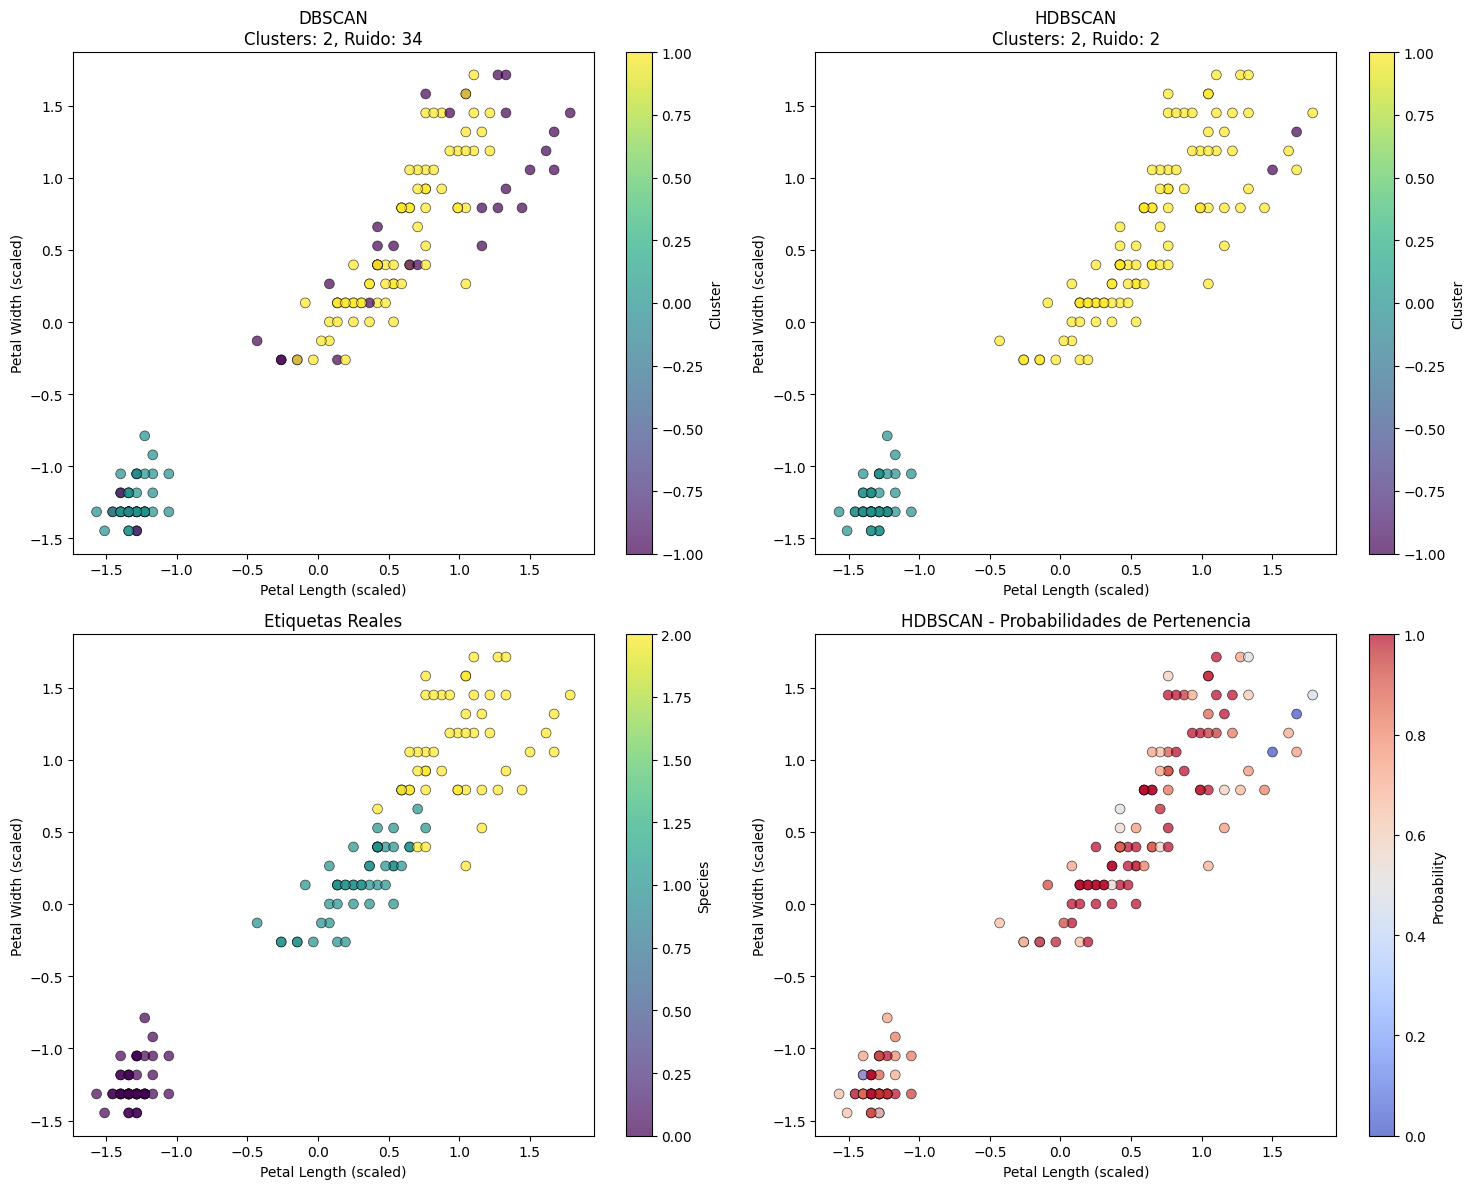

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. DBSCAN
scatter1 = axes[0, 0].scatter(X_2d[:, 0], X_2d[:, 1], 
                              c=labels_dbscan, cmap='viridis', 
                              s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Petal Length (scaled)')
axes[0, 0].set_ylabel('Petal Width (scaled)')
axes[0, 0].set_title(f'DBSCAN\nClusters: {n_clusters_dbscan}, Ruido: {n_noise_dbscan}')
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster')

# 2. HDBSCAN
scatter2 = axes[0, 1].scatter(X_2d[:, 0], X_2d[:, 1], 
                              c=labels_hdbscan, cmap='viridis', 
                              s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Petal Length (scaled)')
axes[0, 1].set_ylabel('Petal Width (scaled)')
axes[0, 1].set_title(f'HDBSCAN\nClusters: {n_clusters_hdbscan}, Ruido: {n_noise_hdbscan}')
plt.colorbar(scatter2, ax=axes[0, 1], label='Cluster')

# 3. Etiquetas Reales
scatter3 = axes[1, 0].scatter(X_2d[:, 0], X_2d[:, 1], 
                              c=y, cmap='viridis', 
                              s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Petal Length (scaled)')
axes[1, 0].set_ylabel('Petal Width (scaled)')
axes[1, 0].set_title('Etiquetas Reales')
plt.colorbar(scatter3, ax=axes[1, 0], label='Species')

# 4. Probabilidades HDBSCAN
scatter4 = axes[1, 1].scatter(X_2d[:, 0], X_2d[:, 1], 
                              c=hdb.probabilities_, cmap='coolwarm', 
                              s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Petal Length (scaled)')
axes[1, 1].set_ylabel('Petal Width (scaled)')
axes[1, 1].set_title('HDBSCAN - Probabilidades de Pertenencia')
plt.colorbar(scatter4, ax=axes[1, 1], label='Probability')

plt.tight_layout()
plt.show()